# 长上下文

> LLaMA 2 训练时只见过 4096 个 token 长度的文本。但今天的模型能处理 128K 甚至 1M——同样的架构，训练时从没见过的长度，推理时居然能用。
>
> 答案在位置编码的外推技术里。这一节从 Attention 的长度瓶颈出发，逐步理解 RoPE 为什么能外推、PI 做了什么、NTK 和 YaRN 又改进了什么，最后学会测试长上下文能力。

长上下文外推（Length Extrapolation）要解决的问题是：模型在训练时只见过位置 0 到 4095 的编码，推理时却要处理位置 10000——这个位置的编码对模型来说是完全陌生的。

解决方案不是重新训练，而是让训练时学到的位置编码规律在更长的序列上继续生效。具体方法取决于位置编码本身的设计：RoPE 用旋转矩阵编码相对位置，天然具备一定的外推能力；PI 压缩位置编号；NTK 调整频率基；YaRN 对不同频率维度做差异化处理。这四种方法构成一条递进的优化路径，也是这一节的主线。

## 1. 什么是外推

**外推**（Extrapolation）= 用已知范围的规律，推测范围之外的情况。

举个生活中的例子：
- 你测过水温 0°C → 冰，50°C → 液体，100°C → 沸腾
- 现在问你：200°C 的水会怎样？你虽然没测过，但根据规律能推断 → 还是气体
- 这就是「外推」

LLM 面临同样的问题：
- 训练时：模型学习了位置 0 到 4095 之间的 attention 规律
- 推理时：用户给了一篇 10000 token 的文章
- 问题：位置 4096~9999 这些位置的 token，模型训练时从没见过，它能正确处理它们吗？

**答案取决于你用什么位置编码。**

## 2. 位置编码回顾

（如果你对 Part 3 的 Embedding + Position 已经很熟，可以跳过这一节。但后面的 RoPE 依赖这个基础，不确定的话最好看一眼。）

Attention 本身是**不关心顺序**的。你把 "猫 坐 垫子" 和 "垫子 坐 猫" 喂给 attention，它算出来的 attention 分数完全相同——因为 attention 只看 token 之间「有多相关」，不看「谁在前谁在后」。

但顺序显然很重要。「我爱你」和「你爱我」意思完全不同。

**位置编码就是给每个 token 贴上一个「我是第几个」的标签**，让 attention 在计算相关性时能用到这个信息。

贴标签有三种方式：

In [1]:
# 直观感受：顺序对 attention 的影响
print("句子 A: 我 爱 你")
print("句子 B: 你 爱 我")
print()
print("没有位置编码时：")
print("  '我' 和 '你' 的 attention 分数完全一样——不管谁在前面")
print("  模型分不清 '我爱你' 和 '你爱我'")
print()
print("有位置编码时：")
print("  '我' 在位置 0 和位置 2 有不同的向量 → attention 可以区分")
print()
print("问题来了：训练时最长只见过 4096 个位置，")
print("推理时来了 10000 个位置 → 第 4097 个位置的「标签」长什么样？")

句子 A: 我 爱 你
句子 B: 你 爱 我

没有位置编码时：
  '我' 和 '你' 的 attention 分数完全一样——不管谁在前面
  模型分不清 '我爱你' 和 '你爱我'

有位置编码时：
  '我' 在位置 0 和位置 2 有不同的向量 → attention 可以区分

问题来了：训练时最长只见过 4096 个位置，
推理时来了 10000 个位置 → 第 4097 个位置的「标签」长什么样？


## 3. 三种位置编码的外推能力

| 方案 | 怎么做 | 代表模型 | 能外推吗？ | 为什么？ |
|------|--------|---------|----------|--------|
| **学出来的位置** | 训练时给每个位置随机初始化一个向量，训练过程中调整 | GPT-2 | ❌ 完全不能 | 只学了 0~1023 位置的向量，1024 位置的向量根本没存在过 |
| **正弦位置编码** | 用 sin/cos 函数手工算每个位置的值，不用学 | 原始 Transformer | 理论上能，实际很差 | 函数本身连续，但模型没学会利用连续性 |
| **RoPE（旋转位置编码）** | 用「旋转」来编码位置，位置差 = 旋转角度差 | LLaMA、Qwen、Mistral | ✅ **可以！** | 相对位置天然具有外推性，且频域特性可以利用 |

RoPE 现在是几乎所有开源 LLM 的标配。我们下面搞懂它。

## 4. RoPE：用旋转编码相对位置

第 2 节回顾了位置编码的基本问题：Attention 本身不区分"我爱你"和"你爱我"。正弦位置编码的解法是在 Input Embedding 上加一个位置向量，让每个 token 的输入表示自带位置信息。

RoPE（Rotary Position Embedding，旋转位置编码）的思路不同。它不修改输入端的 Embedding，而是直接介入 Q 和 K 的点积计算——用旋转矩阵把相对位置信息"写进"点积结果里。

### 4.1 目标：让 Q 和 K 的点积依赖于相对位置

回忆 Attention 的核心操作：位置 m 的 query 向量 q_m 和位置 n 的 key 向量 k_n 做点积，点积值决定了两个 token 之间的 Attention 权重。

没有位置编码时，q_m 和 k_n 的点积只取决于两个 token 的语义内容。同一个词对，不论出现在句首还是句尾，点积完全相同——因为 Embedding 查出来的向量只跟 token ID 有关，跟位置无关。

RoPE 的目标是设计一个操作 f，把位置信息注入到 q 和 k 中，使得点积只依赖于**相对位置 m-n**：

$$f(q_m, m) \cdot f(k_n, n) = g(q_m, k_n, \boxed{m - n})$$

为什么追求"只依赖于 m-n"？考虑一个具体的例子。句子"我 爱 你"里，"爱"在位置 1，"你"在位置 2，距离是 1。句子"昨天 我 爱 你"里，"爱"移到了位置 2，"你"移到了位置 3——但"爱"和"你"之间的距离仍然是 1。在这两个句子里，"爱"和"你"之间的语义关系应该相同。如果点积只依赖于相对距离，距离相同的词对 Attention 就相同，模型就学到了语言中最基本的平移不变性。

正弦位置编码通过加法注入位置，但加法之后的信息是混在一起的——q_m 和 k_n 各自包含绝对位置 m 和 n，它们的点积无法干净地只依赖 m-n。RoPE 通过旋转来实现这个干净的依赖关系。

### 4.2 二维旋转：从一个向量对的旋转入手

先看最简单的情况：向量只有 2 维。平面上一个点 (x, y) 逆时针旋转角度 θ，用旋转矩阵表示：

$$R_\theta = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

旋转后的结果是：

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = R_\theta \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} x\cos\theta - y\sin\theta \\ x\sin\theta + y\cos\theta \end{bmatrix}$$

旋转不改变向量的长度：$\|R_\theta v\| = \|v\|$。这意味着旋转不会扭曲 token 的语义信息——向量的模长（代表语义强度）保持不变，改变的只是方向。

现在把这套到 Attention 上。把位置 m 的查询向量 q_m 旋转一个与 m 成正比的角度 mθ，把位置 n 的键向量 k_n 旋转 nθ。然后算点积：

$$(R_{m\theta}\, q_m)^T (R_{n\theta}\, k_n) = q_m^T R_{m\theta}^T R_{n\theta} k_n$$

关键一步。利用旋转矩阵的两个性质：

**性质一**：$R_\alpha^T = R_{-\alpha}$。旋转矩阵的转置等于反向旋转——把角度取负即可。

**性质二**：$R_{-\alpha} R_\beta = R_{\beta-\alpha}$。先反向转 α°，再正向转 β°，等价于直接转 (β-α)°。

代入得到：

$$q_m^T R_{-\alpha} R_\beta k_n = q_m^T R_{(n-m)\theta}\, k_n$$

等号右边只出现了 $n-m$，不出现单独的 $m$ 或 $n$。m 和 n 各自的绝对位置抵消了，只剩下它们的差。

**这意味着：旋转后 q_m 和 k_n 的点积，只依赖于它们的相对位置 (n-m)，不依赖于它们各自在哪个位置。** 相对位置信息被天然编码进了 Q 和 K 的点积之中。

下面用具体数字手动验证这个性质。设两个向量 q = (1, 1) 和 k = (1, 1)，单位旋转角 θ = 15°，位置 m=2，n=5（距离为 3）。同时再算一组 m=10，n=13（距离也是 3）——如果两组的点积相同，就验证了"只依赖 m-n"。

In [2]:
import math
import torch

# === 手动验证：旋转后点积只依赖于相对位置 ===
# 设 q = (1, 1), k = (1, 1), θ = 15° = π/12
theta = math.pi / 12  # 15 度

def rotate_2d(v, angle):
    """对一个二维向量施加旋转矩阵"""
    x, y = v[0], v[1]
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    x_new = x * cos_a - y * sin_a
    y_new = x * sin_a + y * cos_a
    return torch.tensor([x_new, y_new])

q = torch.tensor([1.0, 1.0])
k = torch.tensor([1.0, 1.0])

# 情况 A：m=2, n=5 → 距离 = 3
q_rot_A = rotate_2d(q, 2 * theta)
k_rot_A = rotate_2d(k, 5 * theta)
dot_A = torch.dot(q_rot_A, k_rot_A)

# 情况 B：m=10, n=13 → 距离也是 3
q_rot_B = rotate_2d(q, 10 * theta)
k_rot_B = rotate_2d(k, 13 * theta)
dot_B = torch.dot(q_rot_B, k_rot_B)

# 情况 C：m=0, n=3 → 距离也是 3（更极端的对比）
q_rot_C = rotate_2d(q, 0 * theta)
k_rot_C = rotate_2d(k, 3 * theta)
dot_C = torch.dot(q_rot_C, k_rot_C)

# 情况 D：m=2, n=6 → 距离 = 4（不同距离，对照）
q_rot_D = rotate_2d(q, 2 * theta)
k_rot_D = rotate_2d(k, 6 * theta)
dot_D = torch.dot(q_rot_D, k_rot_D)

print("=== 手算验证：旋转后点积只依赖于 m-n ===")
print()
print("q = (1, 1), k = (1, 1), 单位角 θ = 15°")
print()
print("情况 A: m=2, n=5  (距离=3)    → 点积 =", f"{dot_A:.6f}")
print("情况 B: m=10, n=13 (距离=3)   → 点积 =", f"{dot_B:.6f}")
print("情况 C: m=0, n=3  (距离=3)    → 点积 =", f"{dot_C:.6f}")
print("情况 D: m=2, n=6  (距离=4)    → 点积 =", f"{dot_D:.6f}")
print()
print("关键观察：")
print("  1. A、B、C 的 m,n 各自不同，但距离都是 3 → 点积完全相同")
print("  2. D 的距离是 4 → 点积与前三组不同")
print("  3. 验证完毕：点积只取决于 n-m，不取决于 m 和 n 各自的绝对位置")
print()
print("这就是 RoPE 最核心的数学性质。")

# 补充：旋转前后点积的变化
dot_original = torch.dot(q, k)
print(f"\n旋转前：q·k = {dot_original:.4f}")
print(f"旋转后（距离=3）：点积 ≈ {dot_A:.4f}")
print(f"相对位置的差异被编码进了点积的数值变化中")

=== 手算验证：旋转后点积只依赖于 m-n ===

q = (1, 1), k = (1, 1), 单位角 θ = 15°

情况 A: m=2, n=5  (距离=3)    → 点积 = 1.414213
情况 B: m=10, n=13 (距离=3)   → 点积 = 1.414214
情况 C: m=0, n=3  (距离=3)    → 点积 = 1.414214
情况 D: m=2, n=6  (距离=4)    → 点积 = 1.000000

关键观察：
  1. A、B、C 的 m,n 各自不同，但距离都是 3 → 点积完全相同
  2. D 的距离是 4 → 点积与前三组不同
  3. 验证完毕：点积只取决于 n-m，不取决于 m 和 n 各自的绝对位置

这就是 RoPE 最核心的数学性质。

旋转前：q·k = 2.0000
旋转后（距离=3）：点积 ≈ 1.4142
相对位置的差异被编码进了点积的数值变化中


## 5. 从二维推广到 d 维

上一节在二维向量上验证了旋转编码相对位置的原理。实际的 q 和 k 通常是 64 或 128 维。怎么把二维旋转推广到 d 维？

### 5.1 d 维向量的分组旋转

方案比想象的直接：把 d 维拆成 d/2 个互不重叠的二维对：

```
对 0: (dim₀, dim₁)    → 在自己的 2D 平面上旋转
对 1: (dim₂, dim₃)    → 在自己的 2D 平面上旋转
...
对 d/2-1: (dim_{d-2}, dim_{d-1}) → 在自己的 2D 平面上旋转
```

每一对独立在自己所属的二维平面上旋转，各对的旋转互不干扰。写成矩阵形式，d 维的旋转矩阵是一个分块对角矩阵——对角线上有 d/2 个 2×2 的小旋转矩阵，其余位置全是 0：

```
R = [R_{θ₀}    0      ...         0      ]
    [  0     R_{θ₁}   ...         0      ]
    [ ...    ...     ...         ...     ]
    [  0      0      ...  R_{θ_{d/2-1}}]
```

在实际代码里不会真的构造这个 d×d 的大矩阵（大部分是 0，浪费计算和显存），而是直接用向量化操作：把相邻维度两两分组，每对独立计算旋转。

### 5.2 每对维度有不同的旋转速度

所有维度对都用同样的转速是不行的——那样所有维度对携带相同的位置信息，浪费了 d 维的表达能力。RoPE 给不同的维度对分配不同的旋转速度。第 i 对的单位旋转角是：

$$\theta_i = \frac{1}{10000^{2i/d}}, \quad i = 0, 1, ..., d/2-1$$

- **i=0**（第一对，dim₀ 和 dim₁）：θ₀ = 1.0，每个位置转 1 弧度（≈ 57°），转得飞快。训练窗口 4096 个位置相当于转了 652 个完整圈，sin/cos 所有可能的值都见过了。它的职责是区分**紧挨着的**两个位置。
- **i=31**（最后一对，dim₆₂ 和 dim₆₃，d=64 时）：θ₃₁ ≈ 0.00013，每个位置只转约 0.008°，极慢。在 4096 个训练位置内只走了约 0.55 弧度（31°），远不到一圈。它的职责是承载**远距离**的位置关系。

这和正弦位置编码的高频/低频设计思路相同，但作用的机制不同：正弦方案是不同频率波形叠加出一个位置向量加在 embedding 上；RoPE 是不同频率的旋转直接作用于 Q 和 K，通过点积编码相对距离。

### 5.3 RoPE 施加在 Q 和 K 上的完整流程

现在可以把 RoPE 的完整计算串起来了。给定一个 token 序列：

1. **Embedding + 投影**：$x_0, x_1, ..., x_{L-1}$ 经过 Embedding 和 Q/K/V 投影矩阵，得到 $q_m = W_Q x_m$，$k_n = W_K x_n$，$v = W_V x$

2. **分组**：每个 q 和 k 按相邻维度两两分组，(dim₀, dim₁) 是第一对，(dim₂, dim₃) 是第二对，以此类推

3. **逐对旋转**：位置 m 的 q 的第 i 对旋转角度 $m \cdot \theta_i$，位置 n 的 k 的第 i 对旋转角度 $n \cdot \theta_i$。用 4.2 节的公式逐对计算旋转后的坐标

4. **点积**：旋转后的 q 和 k 做点积。根据 4.2 节的推导，第 i 对维度对点积的贡献包含 $\cos((n-m)\theta_i)$，整条向量的点积是各对贡献之和——结果只依赖于相对位置 $n-m$

5. **后续不变**：softmax + 乘以 V 的步骤和标准 Attention 完全相同

和正弦位置编码的结构性区别。正弦方案：位置向量加在 Embedding 上，后续 Q/K 投影会混合 token 语义和位置信息。RoPE：位置信息绕过 Embedding，直接作用在 Q 和 K 上，通过旋转矩阵精确控制点积中的位置依赖。V（Value）不参与旋转——因为 Attention 输出中不需要通过 V 来传递位置信息，V 只需要提供被"加权聚合"的内容即可。

下面用代码实现完整的 RoPE，并验证它的相对位置性质。

In [3]:
# 直接看：不同维度对的旋转速度差多少
import torch
import math

d_k = 64          # 总共 64 维，两两结对 → 32 对
base = 10000      # RoPE 默认 base

pair_indices = torch.arange(0, d_k, 2).float()  # [0, 2, 4, ..., 62]
freqs = 1.0 / (base ** (pair_indices / d_k))

print(f"共 {len(freqs)} 对维度")
print(f"第 0 对（最快）频率: {freqs[0]:.4f}  → 每位置转 {math.degrees(freqs[0]):.1f}°")
print(f"第 16 对（中等）频率: {freqs[16]:.6f}  → 每位置转 {math.degrees(freqs[16]):.4f}°")
print(f"第 31 对（最慢）频率: {freqs[31]:.8f}  → 每位置转 {math.degrees(freqs[31]):.6f}°")

slowest_period = 2 * math.pi / freqs[31]
print(f"\n最慢那对走完一圈需要 {slowest_period:.0f} 个位置")
# → 训练窗口 4096，最慢的指针连一圈都没走完 → 这就是外推的瓶颈


共 32 对维度
第 0 对（最快）频率: 1.0000  → 每位置转 57.3°
第 16 对（中等）频率: 0.010000  → 每位置转 0.5730°
第 31 对（最慢）频率: 0.00013335  → 每位置转 0.007641°

最慢那对走完一圈需要 47117 个位置


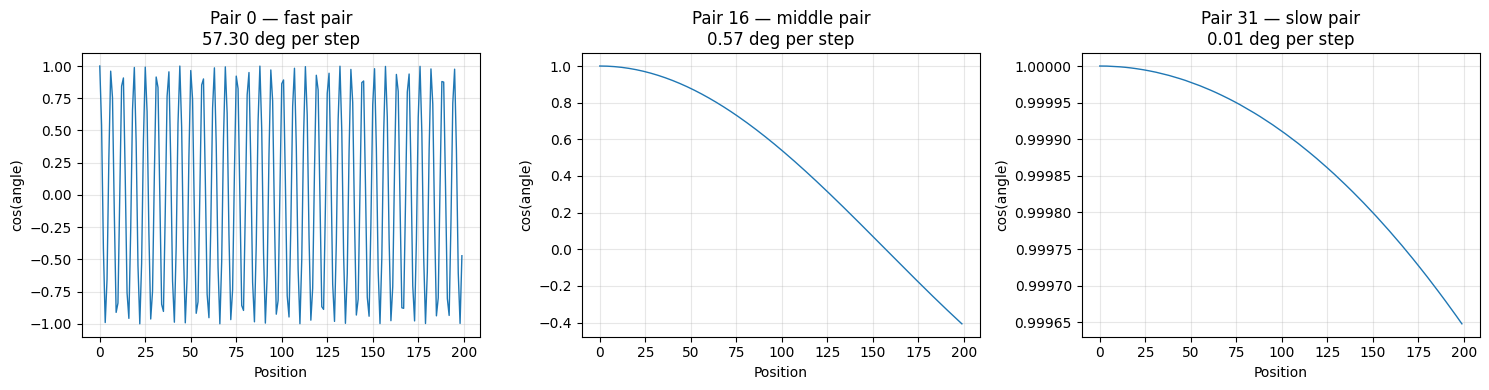

In [4]:
# 画出来：不同维度的指针随位置移动（cos 值）
import torch
import matplotlib.pyplot as plt

seq_len = 200
positions = torch.arange(seq_len).float()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, (pair_idx, label) in enumerate([
    (0, "fast pair"),
    (16, "middle pair"),
    (31, "slow pair")
]):
    theta = positions * freqs[pair_idx]
    ax = axes[ax_idx]
    ax.plot(positions.numpy(), theta.cos().numpy(), linewidth=1)
    ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
    ax.set_title(f'Pair {pair_idx} — {label}\n{math.degrees(freqs[pair_idx]):.2f} deg per step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# 左边转了好几圈（密集波形）→ 高频 → 区分邻居
# 右边不到半圈（缓慢曲线）→ 低频 → 承载远距离信息


## 6. 直接外推为什么失败

训练时最长序列是 4096。推理时来了 8192 个 token。最简单的想法：让 RoPE 按正常规则往后数——位置 4097, 4098, …, 8191，正常用 m×θ_i 算旋转角。行不行？

结论是：不行。但理解**为什么**不行，是掌握所有外推方法的关键。

### 6.1 快维度和慢维度的差异

从第 5 节我们知道，不同的维度对转速差异极大。这意味着在 4096 个训练位置内，不同维度经历的角度范围不同，它们的"阅历"也不同。下面这张表列出了 d=64 时几个典型维度对在训练窗口内的情况：

| 维度对 | 频率 θ_i | 训练窗内转动总角度 | 折合圈数 | sin/cos 见过的范围 |
|:---|:---|:---|:---|:---|
| i=0（最快） | 1.0 | 4096 rad | ~652 圈 | 全部 [-1, 1]，所有形状 |
| i=8 | ~0.1 | ~410 rad | ~65 圈 | 全部 [-1, 1] |
| i=16 | ~0.01 | ~41 rad | ~6.5 圈 | 全部 [-1, 1] |
| i=24 | ~0.001 | ~4.1 rad | ~0.65 圈 | 约 0.65 个周期的 sin/cos，[-1, 1] 的约 65% |
| i=31（最慢） | ~0.00013 | ~0.55 rad | ~0.09 圈 | 约 0.09 个周期的 sin/cos，[0, 0.52] 区间 |

**核心观察**：快维度（i≤16）在 4096 个位置内转了很多整圈，sin 和 cos 在 [-1, 1] 之间的各种值——上升、下降、波峰、波谷、拐点——都反复见过了。它们对任何角度值都有充分的训练。

慢维度（i≥24）则不然。i=31 那对在整个训练窗口内只转了约 31°（0.55 弧度），连一圈的 1/10 都不到。它们只见过 cos 从 1 缓慢降到 0.85、sin 从 0 升到 0.52 这段小区间。**任何超出这个区间的角度值，对它们来说都是完全陌生的。**

### 6.2 外推触碰了陌生角度

当推理长度扩展到 8192 时，位置 8191 在最快维度上的角度是 8191 弧度，但由于已经转过很多圈，8191 rad mod 2π 仍然在熟知的范围内——快维度对任何角度值都有经验。

问题出在慢维度。i=31 在位置 8191 的角度是 8191 × 0.00013 ≈ 1.1 弧度（63°）。在 4096 的训练窗口内，这个维度最大只见过 0.55 弧度（31°）。63° 远远超出了训练范围——sin(63°) ≈ 0.89 和 cos(63°) ≈ 0.45 这两个值，模型从未在这个维度上见过。

这就引出了一个关键认识：**不是所有维度都有外推问题。只有那些在训练窗口内没走完一圈的慢维度，才会在超长位置遇到陌生角度。** 快维度转了很多圈，什么角度都见过，可以直接外推。

这解释了为什么学出来的位置编码（GPT-2）完全不能外推——它的每一维都是一个独立的、只在训练窗口内学过的值，没有"转圈"的概念，所有维度等价于"没走完一圈的慢维度"。也解释了为什么正弦位置编码理论上能外推但实际效果差——虽然所有维度都用 sin/cos，但模型很难学会利用这种连续性的外推能力。而 RoPE 天然暴露了不同维度的频域结构，这恰好给了我们一个可以操作的杠杆。

### 6.3 用时钟来理解

快维度：一个走了 652 圈的秒针——什么地方都去过，经验丰富。慢维度：一个只在 0° 到 31° 之间来回摆动的时针——只熟悉这个小区间。现在让它指向 63°，它无法理解。

下面画出 i=31 这个最慢维度在训练窗口内外的余弦值，直观感受"角度超标"。

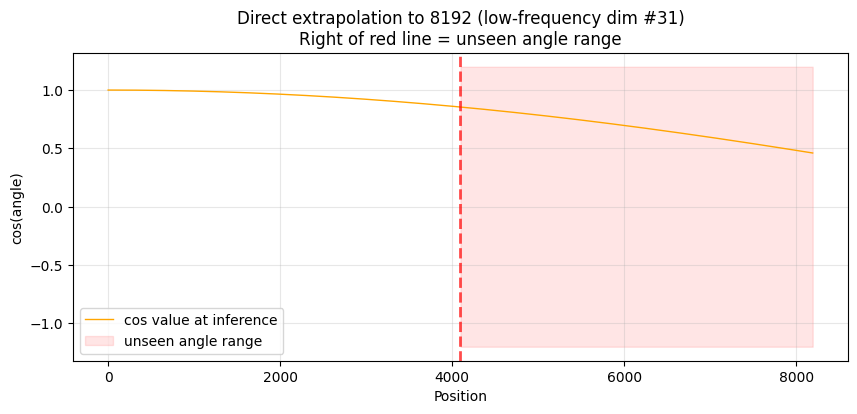

训练时最大角度: 31.3°  →  外推后最大角度: 62.6°  →  超出 31.3°


In [5]:
# 直接外推的问题：低频维度在训练窗口外角度超标
import torch
import matplotlib.pyplot as plt
import math

train_len, extrap_len = 4096, 8192
slow_pair = 31

positions_train = torch.arange(train_len).float()
positions_extrap = torch.arange(extrap_len).float()
theta_train = positions_train * freqs[slow_pair]
theta_extrap = positions_extrap * freqs[slow_pair]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(positions_extrap.numpy(), theta_extrap.cos().numpy(),
        linewidth=1, color='orange', label='cos value at inference')
ax.axvline(x=train_len, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between(range(train_len, extrap_len), -1.2, 1.2,
                alpha=0.1, color='red', label='unseen angle range')
ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
ax.set_title(f'Direct extrapolation to 8192 (low-frequency dim #{slow_pair})\nRight of red line = unseen angle range')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# 训练时角度 0~{train_deg:.0f}°，外推时到了 {extrap_deg:.0f}°，超出 {over:.0f}°
train_deg = math.degrees(theta_train[-1].item())
extrap_deg = math.degrees(theta_extrap[-1].item())
print(f"训练时最大角度: {train_deg:.1f}°  →  外推后最大角度: {extrap_deg:.1f}°  →  超出 {extrap_deg - train_deg:.1f}°")


## 7. 核心思想：控制角度范围

第 6 节的结论很明确：外推失败不是因为 RoPE 本身有缺陷，而是因为慢维度的旋转角超出了训练范围。快维度没有问题。

**解决思路：想办法让位置 4096~8191 在慢维度上产生的角度，也落在训练时见过的 [0, 训练最大角] 区间内。对快维度尽量不干预——它们已经见过各种角度，不需要额外处理。**

### 7.1 三种压缩策略的直觉

把模型想象成一个只认识 0 到 4095 号门牌的人。现在要让它识别 4096 到 8191 号，有三种策略：

**PI（Position Interpolation）**：把所有门牌号除以 2。新 4096 号被映射回旧 2048 号，新 8191 号被映射回旧 4095 号——全都在认识的范围里。代价是原来区别清楚的 1 号和 2 号，现在变成了 0.5 号和 1 号，区分能力下降。

**NTK-aware**：只压缩"不太认识"的慢维度，不碰"已经很熟"的快维度。通过一个参数（base 值）的调整，利用频率公式自身的非线性，自动完成差异化压缩。

**YaRN**：在 NTK 基础上进一步细化。维度不是简单的"快"和"慢"二分——中间那些"不快不慢"的维度需要平滑过渡。此外，压缩后 Attention 的 softmax 分布会变化，需要温度修正来校准。

### 7.2 从频率公式看三种方法的差异

所有方法归根结底都在改这个公式中的参数：

$$\theta_i = \frac{1}{10000^{2i/d}}$$

- **PI**：不碰 θ_i，而是把位置 m 替换为 m/scale。等效于所有 θ_i 等比缩小 scale 倍。所有频率同步变慢。

- **NTK-aware**：不碰位置 m，而是把 10000 替换为 $10000 \times scale^{d/(d-2)}$。因为分母是 $base^{2i/d}$，指数依赖导致：小 i（快维度）分母变化小 → 频率几乎不变；大 i（慢维度）分母变化大 → 频率大幅降低。一个参数实现了差异化。

- **YaRN**：在 NTK 改 base 的基础上，对每个维度 i 计算其波长（走完一圈所需的 token 数）$\lambda_i = 2\pi / \theta_i$。根据 λ_i 和目标长度的关系，将维度分为三段：λ_i 很短的维度不缩放，λ_i 很长的维度缩放到 scale 倍，中间的维度平滑过渡。温度修正则处理 Attention 分布 sharpness 的变化。

它们之间的关系不是并列的三种"方法"，而是一条理解逐步加深的递进路径：PI 发现了"压缩"这件事 → NTK 发现了"只需要压缩慢维度" → YaRN 发现了"压缩需要分段平滑 + 温度校准"。

下面的三节逐一展开每种方法的具体做法和代码。

## 8. 方法一：Position Interpolation

**论文**: Meta, 2023 — Extending Context Window via Position Interpolation

想法：把位置编号直接**等比例压缩**。

```
目标: 把 4096 窗口扩展到 8192
缩放因子 α = 4096 / 8192 = 0.5

新位置 = 真实位置 × 0.5

真实位置 0    → 给模型的位置 = 0 × 0.5 = 0
真实位置 2048 → 给模型的位置 = 2048 × 0.5 = 1024
真实位置 8192 → 给模型的位置 = 8192 × 0.5 = 4096 ← 刚好落在训练边界！
```

**打个比方**：你家门牌号是 1 到 100 号，你只认识 1-50 号。现在来了 51-100 号，你把所有号码除以 2——51 号变成 25.5 号，100 号变成 50 号，全都在你认识的范围内。

**代价**：所有门牌号都被压缩了。原来能清楚区分 1 号和 2 号，现在 1 号和 2 号变成了 0.5 号和 1 号，差别变小了——近程分辨力下降。

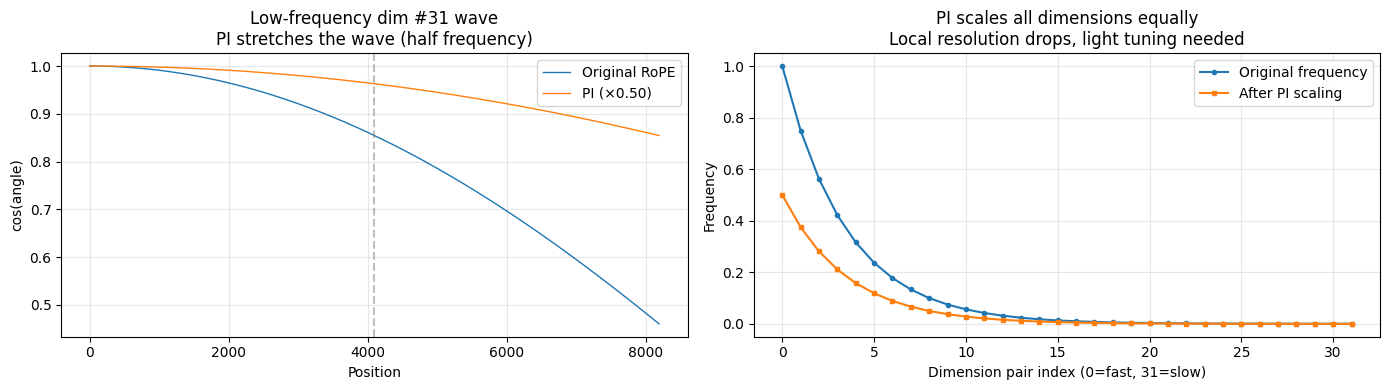

In [6]:
# PI 的实现：位置 × 缩放因子，再正常算 RoPE
import torch
import matplotlib.pyplot as plt

train_len, target_len = 4096, 8192
alpha = train_len / target_len  # 0.5

pair_indices = torch.arange(0, 64, 2).float()
freqs_orig = 1.0 / (10000 ** (pair_indices / 64))
freqs_pi = freqs_orig * alpha

# 原始 RoPE vs PI 压缩后的波形
positions_orig = torch.arange(target_len).float()
angles_orig = positions_orig * freqs_orig[31]
positions_pi = torch.arange(target_len).float() * alpha
angles_pi = positions_pi * freqs_orig[31]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(angles_orig.cos().numpy(), linewidth=1, label='Original RoPE')
axes[0].plot(angles_pi.cos().numpy(), linewidth=1, label=f'PI (×{alpha:.2f})')
axes[0].axvline(x=train_len, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Position'); axes[0].set_ylabel('cos(angle)')
axes[0].set_title(f'Low-frequency dim #{31} wave\nPI stretches the wave (half frequency)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 右：所有维度频率被等比例压缩
axes[1].plot(freqs_orig.numpy(), 'o-', markersize=3, label='Original frequency')
axes[1].plot(freqs_pi.numpy(), 's-', markersize=3, label='After PI scaling')
axes[1].set_xlabel('Dimension pair index (0=fast, 31=slow)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PI scales all dimensions equally\nLocal resolution drops, light tuning needed')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. 方法二：NTK-aware

**论文**: NTK-Aware Scaled RoPE, bloc97, 2023

PI 的毛病：它对**所有**维度一视同仁地压缩。但从第 5 节我们知道，不同维度转的速度不一样：
- 快的维度（秒针）：在 4096 个位置内已经转了好多圈，各种角度都见过了 → **不需要压缩**
- 慢的维度（时针）：4096 个位置内连一圈都没走完，没见过的角度多 → **需要压缩**

所以 NTK-aware 的想法是：**只压慢的，不压快的。**

怎么做到？**把 base 从 10000 改大。** 这是 NTK-aware 最巧妙的地方：

```
频率公式: freq_i = 1 / base^(2i/d)

base = 10000 → 频率快 → 慢维度也走不完一圈
base = 100000 → 频率变慢 → 慢维度走得更慢 → 在同样位置内角度更小 → 不超出训练范围！

而且：
  低 i（快维度）: freq ≈ 1 → 改 base 几乎不影响 ← 快的不用调
  高 i（慢维度）: freq ≈ 1/base → 改 base 影响大 ← 慢的调得多
```

这恰好实现了「快手不调，慢手多调」！**一个参数的改动，自动完成了差异化压缩。**

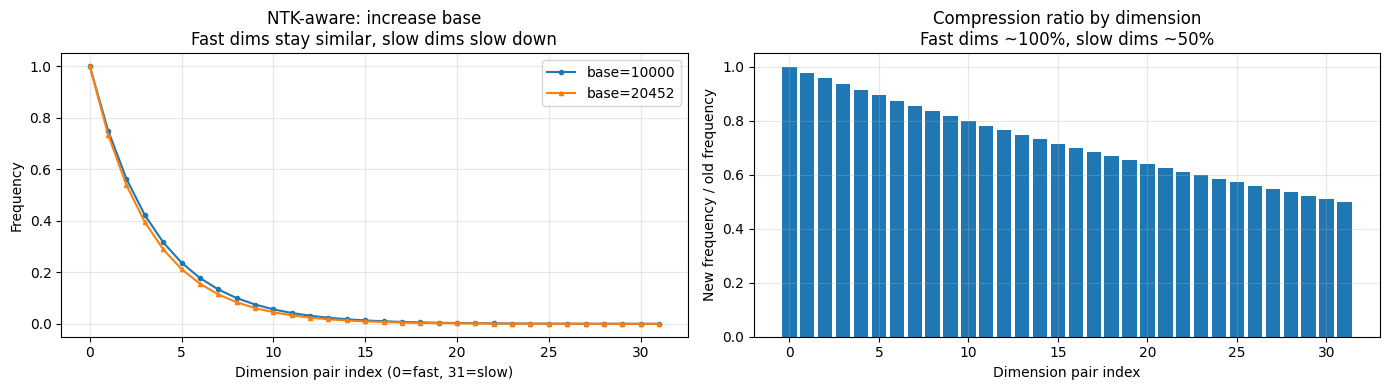

In [7]:
# 演示 NTK：改 base 对不同维度的影响
import torch
import matplotlib.pyplot as plt

base_old, scale = 10000, 2
# NTK 公式：新 base = 旧 base × scale^(d/(d-2))
base_new = base_old * (scale ** (64 / 62))

pair_indices = torch.arange(0, 64, 2).float()
freqs_old = 1.0 / (base_old ** (pair_indices / 64))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs_old.numpy(), 'o-', markersize=3, label=f'base={base_old}')
axes[0].plot(freqs_new.numpy(), '^-', markersize=3, label=f'base={base_new:.0f}')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('NTK-aware: increase base\nFast dims stay similar, slow dims slow down')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 每个维度的压缩比
ratio = freqs_new / freqs_old
axes[1].bar(range(len(ratio)), ratio.numpy())
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('New frequency / old frequency')
axes[1].set_title('Compression ratio by dimension\nFast dims ~100%, slow dims ~50%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# NTK 只需把 base 从 10000 改到 ~86000，不改模型结构，大多数情况不需微调


## 10. 方法三：YaRN

**论文**: YaRN, 2023

NTK 已经很好了，但 YaRN 发现了一个问题：改 base 之后，中间那些维度（不快不慢的）的 attention 会变得「不够果断」。

什么意思？回想 attention 的 softmax 步骤：

```
softmax([2, 1, 0.5]) → [0.59, 0.22, 0.13, 0.06]  ← 比较「尖锐」，注意力集中
softmax([1, 0.5, 0.25]) → [0.42, 0.26, 0.19, 0.14] ← 比较「平滑」，注意力分散
```

用「温度」可以调节 softmax 的尖锐程度：
```
温度低 → softmax 更尖锐 → 注意力更集中 → 适合近程信息
温度高 → softmax 更平滑 → 注意力更分散 → 适合远程信息（反正远距离也不需要精确到哪个 token）
```

**YaRN 的做法：NTK 改 base + 对不同维度组做分段缩放/调节。** 它是常见的强基线之一，但不是所有模型和任务上的“唯一最优”。后续还有 LongRoPE、LongRoPE2 这类极长上下文方法。

- 快维度：温度 = 1（不调，保持精确）
- 中间维度：温度平滑过渡
- 慢维度：温度稍高（让远程 attention 更平滑）

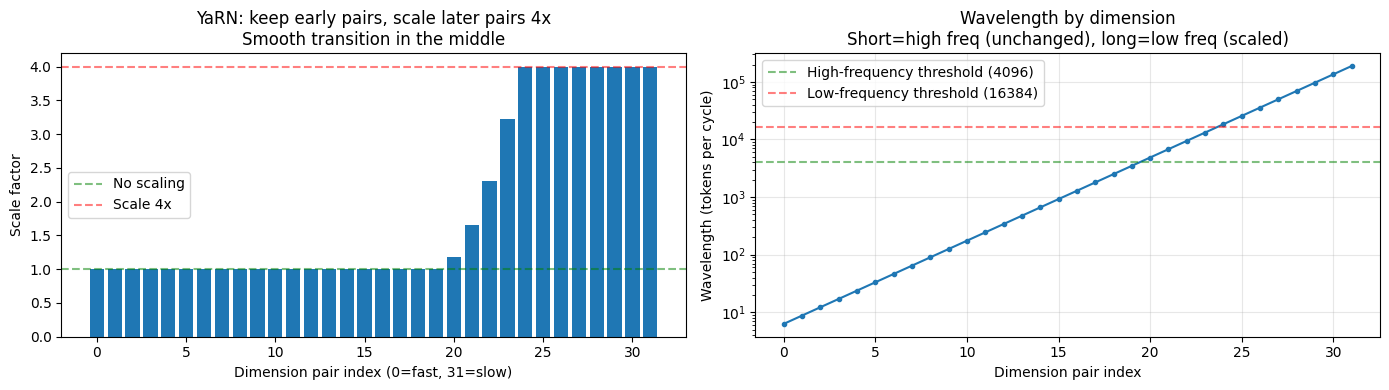

In [8]:
# YaRN 的分段策略：根据波长把维度分成三组
import torch
import matplotlib.pyplot as plt
import math

scale, target_len = 4, 16384
pair_indices = torch.arange(0, 64, 2).float()
base_new = 10000 * (scale ** (64 / 62))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))
wavelengths = 2 * math.pi / freqs_new  # 走完一圈需要的位置数

# 分段阈值
low_bound = target_len / 1.0    # 波长 > 此值 → 低频（需缩放）
high_bound = target_len / 4.0   # 波长 < 此值 → 高频（不缩放）

# ramping: 从 0（不调）平滑过渡到 1（缩放 scale 倍）
smooth = torch.clamp((wavelengths - high_bound) / (low_bound - high_bound), 0.0, 1.0)
dim_scale = (1 - smooth) * 1.0 + smooth * scale

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(32), dim_scale.numpy())
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='No scaling')
axes[0].axhline(y=scale, color='red', linestyle='--', alpha=0.5, label=f'Scale {scale}x')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Scale factor')
axes[0].set_title(f'YaRN: keep early pairs, scale later pairs {scale}x\nSmooth transition in the middle')
axes[0].legend()

axes[1].plot(wavelengths.numpy(), 'o-', markersize=3)
axes[1].axhline(y=high_bound, color='green', linestyle='--', alpha=0.5, label=f'High-frequency threshold ({high_bound:.0f})')
axes[1].axhline(y=low_bound, color='red', linestyle='--', alpha=0.5, label=f'Low-frequency threshold ({low_bound:.0f})')
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('Wavelength (tokens per cycle)')
axes[1].set_yscale('log'); axes[1].set_title('Wavelength by dimension\nShort=high freq (unchanged), long=low freq (scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# YaRN = NTK 改 base + 分段平滑过渡，是常见强基线之一


## 11. 三大方法一句话总结

| 方法 | 一句话 | 怎么做到的 | 需要微调？ |
|------|--------|----------|----------|
| **PI** | 把所有门牌号 ÷ 2 | 位置编号 × 缩放因子 | 需要 |
| **NTK** | 调慢时钟的转速 | 改大 RoPE 的 base 值 | 不需要 |
| **YaRN** | NTK + 对不同维度分段处理 | 改 base + 分段平滑过渡 | 通常不需要或少量微调 |

**最重要的实用知识**：大多数情况下，你只需要在模型配置文件里把 `rope_theta`（base 值）改大就行：
- 4K → 8K：改到 500000 左右
- 4K → 32K：改到 1000000 左右

LLaMA 3 就是这么做的——把 base 从 10000 改到 500000，直接 8K → 32K。

In [9]:
# 完整代码：一个支持三种外推策略的 RoPE 模块
import torch
import torch.nn as nn

class ExtrapolatableRoPE(nn.Module):
    """支持 PI / NTK / YaRN 三种外推策略的 RoPE"""

    def __init__(self, d_k, max_seq_len=4096, base=10000, strategy='ntk'):
        super().__init__()
        self.d_k = d_k
        self.max_seq_len = max_seq_len
        self.base = base
        self.strategy = strategy
        self._update_cache(max_seq_len, base)

    def _update_cache(self, seq_len, base, pi_scale=1.0):
        """重新计算 cos/sin 缓存"""
        positions = torch.arange(seq_len).float() / pi_scale
        freq = 1.0 / (base ** (torch.arange(0, self.d_k, 2).float() / self.d_k))
        angles = positions.unsqueeze(1) * freq.unsqueeze(0)
        cos = angles.cos().repeat_interleave(2, dim=-1)
        sin = angles.sin().repeat_interleave(2, dim=-1)
        self.register_buffer('cos', cos)
        self.register_buffer('sin', sin)

    def set_extrapolation(self, target_len):
        """设置外推目标长度"""
        if target_len <= self.max_seq_len:
            return

        scale = target_len / self.max_seq_len

        if self.strategy == 'pi':
            self._update_cache(target_len, self.base, pi_scale=scale)
        elif self.strategy == 'ntk':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)
        elif self.strategy == 'yarn':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)  # 简化版，实际 YaRN 还有温度

        print(f"外推: {self.max_seq_len} → {target_len} (策略={self.strategy})")

    def forward(self, q, k, offset=0):
        """对 Q 和 K 施加旋转"""
        seq_len = q.shape[-2]
        cos = self.cos[offset:offset + seq_len].to(q.device)
        sin = self.sin[offset:offset + seq_len].to(q.device)

        q_rot = q * cos + (torch.stack([-q[..., 1::2], q[..., ::2]], dim=-1).flatten(-2) * sin)
        k_rot = k * cos + (torch.stack([-k[..., 1::2], k[..., ::2]], dim=-1).flatten(-2) * sin)
        return q_rot, k_rot

# 测试
rope = ExtrapolatableRoPE(d_k=64, max_seq_len=4096, strategy='ntk')
rope.set_extrapolation(32768)

q = torch.randn(1, 1, 100, 64)
k = torch.randn(1, 1, 100, 64)
q_rot, k_rot = rope(q, k)
print(f"Q: {q.shape} → 旋转后: {q_rot.shape}")


外推: 4096 → 32768 (策略=ntk)
Q: torch.Size([1, 1, 100, 64]) → 旋转后: torch.Size([1, 1, 100, 64])


## 12. 长上下文的验证方法

你把上下文从 4K 扩展到了 32K，怎么证明它真的「读懂」了长文本？不能只靠感觉。

**探针测试 = 设计一个只有读懂了全文才能答对的题。** 如果模型在长文本上答对了，说明它对远距离 token 的 attention 是有效的。

#### 12.1 大海捞针（Needle in a Haystack）— 最经典的测试

做法很简单：
1. 生成一大段无关文本（"干草堆"），比如一篇 32K token 的文章
2. 在某个位置塞入一句话（"针"），比如「密码是 12345」
3. 问模型：「密码是什么？」
4. 如果模型能从 32K 的文本中找到并答对这个密码 → 说明这个位置的 attention 是好的

把针放在不同位置（开头、中间、结尾），用不同长度的文本（1K、2K、4K、...、32K），每种组合都测一遍 → 画出热力图。

In [10]:
# 大海捞针测试矩阵（模拟）：不同长度 × 不同位置
context_lengths = [1024, 2048, 4096, 8192, 16384, 32768]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]  # 针的位置（0=开头, 1=结尾）

# 模拟结果：✅=答对, ❌=答错
results = [
    [True,  True,  True,  True,  True ],   # 1K
    [True,  True,  True,  True,  True ],   # 2K
    [True,  True,  True,  True,  True ],   # 4K
    [True,  True,  True,  True,  True ],   # 8K
    [True,  True,  False, True,  True ],   # 16K — 中间丢了
    [True,  False, False, True,  True ],   # 32K — 前中也丢了
]

print("大海捞针测试矩阵:")
print(f"{'长度':<8}", *[f"{p:.0%}位  " for p in positions])
for i, cl in enumerate(context_lengths):
    print(f"{cl:<8}", *[f"{'✅' if r else '❌'}   " for r in results[i]])
# Lost in the Middle: 中间位置的针更容易丢

大海捞针测试矩阵:
长度       0%位   25%位   50%位   75%位   100%位  
1024     ✅    ✅    ✅    ✅    ✅   
2048     ✅    ✅    ✅    ✅    ✅   
4096     ✅    ✅    ✅    ✅    ✅   
8192     ✅    ✅    ✅    ✅    ✅   
16384    ✅    ✅    ❌    ✅    ✅   
32768    ✅    ❌    ❌    ✅    ✅   


#### 12.2 比大海捞针更狠的测试：RULER

大海捞针只测了「找一句话」的能力。RULER 更全面：

| 测试 | 做什么 | 为什么更难 |
|------|--------|----------|
| **多针召回** | 藏 3 个不同的信息，问 3 次 | 需要同时在多处保持 attention |
| **多跳推理** | 开头说 A=1，结尾说 B=A+1，问 B | 需要把两个远距离信息组合起来推理 |
| **变量追踪** | 跟踪一个值在文章中的多次变化 | 需要更新记忆 |
| **词频统计** | 数某个词在全文出现了几次 | 需要遍历全文并计数 |

**多跳推理是最能暴露问题的**：
```
文章 10% 位置: "公司 A 的营收是 100 亿"
文章 90% 位置: "公司 B 的营收是 A 的 2 倍"
问: "公司 B 的营收是多少？"

模型需要：
  1. 找到 10% 位置的信息 → 100 亿
  2. 找到 90% 位置的信息 → 2 倍
  3. 组合推理 → 200 亿
```
这比单纯的「找一句话」难得多，因为它要求模型同时对开头和结尾保持精确 attention。

In [11]:
# 多跳推理探针示例：需要同时记住多个远距离信息
print("=== 多跳推理探针（模拟）===")
print(f"文章: 32K tokens")
print(f"  5%  位置: 苹果 5 元/个")
print(f"  50% 位置: 小明买 3 个")
print(f"  95% 位置: 满 10 减 2")
print(f"  问题: 小明付多少？ → 答案: 5×3=15, 满10减2 = 13 元")
print(f"\n需要 5%→50%→95% 三次跳转，缺一个就答错")
# 答 15 元 → 漏了结尾的优惠信息
# 答不知道 → 一个信息都没找到

=== 多跳推理探针（模拟）===
文章: 32K tokens
  5%  位置: 苹果 5 元/个
  50% 位置: 小明买 3 个
  95% 位置: 满 10 减 2
  问题: 小明付多少？ → 答案: 5×3=15, 满10减2 = 13 元

需要 5%→50%→95% 三次跳转，缺一个就答错


#### 12.3 PPL 曲线 — 直接看「模型有多困惑」

**Perplexity (PPL)** = 困惑度。越低越好，越低表示模型对下一个 token 越「有把握」。

最好的测试：把同样一篇长文喂给模型，看在训练窗口边界（4096）处 PPL 会不会突然涨。

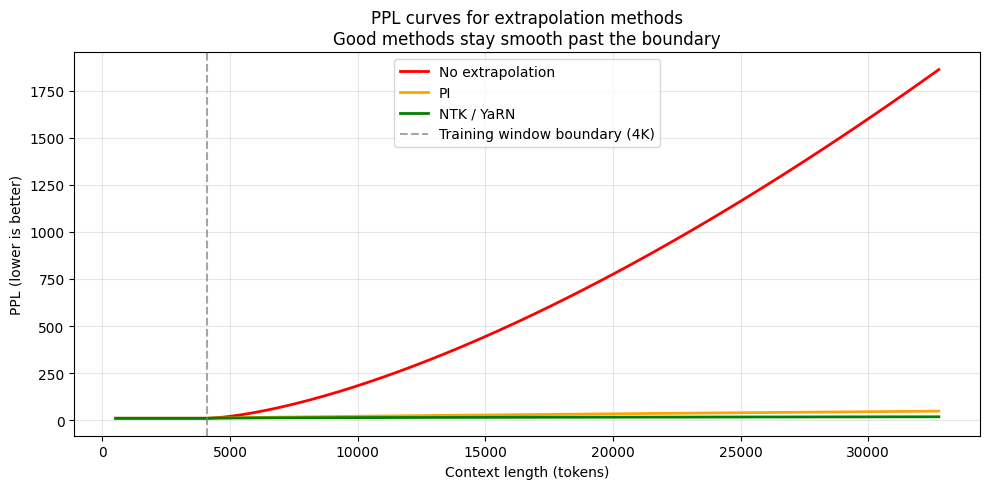

In [12]:
# 模拟 PPL 曲线：不同外推方案在窗口边界外的表现
import torch
import matplotlib.pyplot as plt

lengths = torch.linspace(512, 32768, 100)
ppl_none, ppl_pi, ppl_ntk = [], [], []

for L in lengths:
    if L <= 4096:
        ppl_none.append(10.0); ppl_pi.append(10.0); ppl_ntk.append(10.0)
    else:
        over = (L - 4096) / 4096
        ppl_none.append(10 + 100 * over**1.5)   # 直接爆炸
        ppl_pi.append(10 + 8 * over**0.8)         # 缓慢涨
        ppl_ntk.append(10 + 3 * over**0.5)        # 几乎不涨

plt.figure(figsize=(10, 5))
plt.plot(lengths.numpy(), ppl_none, label='No extrapolation', linewidth=2, color='red')
plt.plot(lengths.numpy(), ppl_pi, label='PI', linewidth=2, color='orange')
plt.plot(lengths.numpy(), ppl_ntk, label='NTK / YaRN', linewidth=2, color='green')
plt.axvline(x=4096, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Training window boundary (4K)')
plt.xlabel('Context length (tokens)'); plt.ylabel('PPL (lower is better)')
plt.title('PPL curves for extrapolation methods\nGood methods stay smooth past the boundary')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# ✅ 好的外推：PPL 过 4096 后平滑  |  ❌ 差的：PPL 猛烈爆炸


#### 12.4 Lost in the Middle — 一个所有模型都有的「病」

即使外推做得再好，有一个问题目前还解决不了：**模型天然更容易关注文章的开头和结尾，而忽略中间部分。**

这叫 **"Lost in the Middle"** 现象。

为什么？因为 attention 机制的 softmax 会让权重「争夺」总和为 1。开头和结尾有结构优势：
- 开头的 token 被所有后续 token 看到（因果 attention 的起点）
- 结尾的 token 离当前生成位置最近（recency bias）
- 中间的就两头不沾了

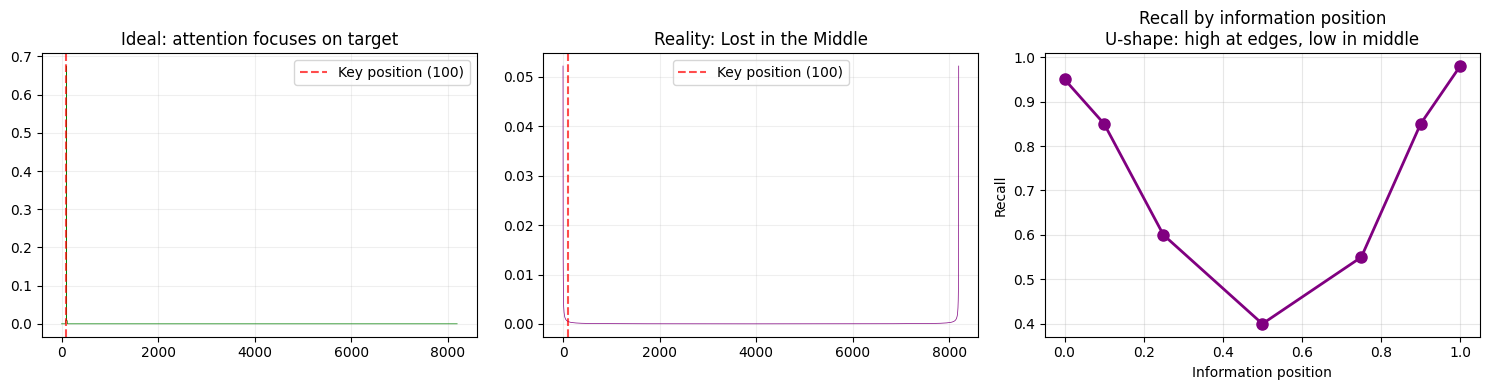

In [13]:
# 可视化 "Lost in the Middle"：中间信息天然被忽略
import torch
import matplotlib.pyplot as plt

seq_len = 8192; target_pos = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ✅ 理想：attention 集中在关键位置
ideal_attn = torch.zeros(seq_len)
ideal_attn[target_pos] = 0.8
ideal_attn[max(0, target_pos-20):target_pos+20] += 0.01
ideal_attn /= ideal_attn.sum()
axes[0].plot(ideal_attn.numpy(), linewidth=0.5, color='green')
axes[0].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[0].set_title('Ideal: attention focuses on target'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# ⚠ 实际：Lost in the Middle → attention 在首尾，中间低
u_shape = 1.0/(1+torch.arange(seq_len).float()) + 1.0/(1+torch.arange(seq_len-1,-1,-1).float())
u_shape /= u_shape.sum()
axes[1].plot(u_shape.numpy(), linewidth=0.5, color='purple')
axes[1].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[1].set_title('Reality: Lost in the Middle'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

# Recall 率：U 形曲线
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
recall_rates = [0.95, 0.85, 0.60, 0.40, 0.55, 0.85, 0.98]
axes[2].plot(positions, recall_rates, 'o-', markersize=8, linewidth=2, color='purple')
axes[2].set_xlabel('Information position'); axes[2].set_ylabel('Recall')
axes[2].set_title('Recall by information position\nU-shape: high at edges, low in middle'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
# 这是结构性问题，不是改 RoPE 能解决的。实际使用中重要信息放首尾。


## 13. 工程真相：长上下文不只是算法问题

即使位置外推方法有效，长上下文还有一个硬瓶颈：**显存和注意力计算**。

回顾 支线 14 讲的 KV Cache：每生成一个新 token，之前所有 token 的 K 和 V 都要存着。序列越长，KV Cache 越大：

```
4K 上下文  → KV Cache ≈ 2GB   （一张家用显卡够用）
32K 上下文 → KV Cache ≈ 16GB  （A100 勉强）
128K 上下文 → KV Cache ≈ 64GB  （需要多卡）
1M 上下文  → KV Cache ≈ 500GB （必须特殊技术）
```

工程上的补救方案：
- **量化 KV Cache**：用 8-bit 甚至 4-bit 存 K 和 V，省 2~4 倍显存
- **Ring Attention**：把一条长序列切成多段，分给多张 GPU，每张 GPU 负责一段
- **StreamingLLM**：保留开头几个「锚点」token + 最近的一批 token，中间扔掉不管

### 13.1 Sliding Window Attention — 限制注意力范围降低计算量

PI、NTK、YaRN 主要处理位置编码外推问题：让模型能计算训练窗口之外的位置表示；质量是否稳定还要看训练和评测。但还有一个更直接的问题：即使位置编码是完美的，标准 causal attention 的计算量本身就让长序列不现实。

标准 causal attention 中，每个 token 关注所有历史 token。序列长度 N 时，attention 打分矩阵是 N×N，计算量按 O(N²) 增长；KV Cache 本身不是 O(N²)，而是按序列长度线性增长：每层为每个历史 token 保存 K 和 V。N=128K 时，单层 attention 矩阵有 16B 个元素，FP32 下超过 64GB 显存——这说明全量 attention 的中间结果和计算都非常昂贵；与此同时，线性增长的 KV Cache 在大模型、多层、多并发下也会迅速吃掉显存。

Sliding Window Attention 的做法很直接：每个 token 不再关注全部历史，只看最近 W 个 token。W 是窗口大小，是一个固定的常数（比如 4096）。这样 attention 计算量从 O(N²) 变成 O(W·N)——随序列长度线性增长，而不是平方增长。

以 W=4096 为例，N=128K 时标准 attention 要做 16B 次点积，Sliding Window 只做 524M 次——减少了 97%。KV Cache 也可以相应缩小：每层只保留最近 4096 个 token 的 K 和 V，而不是全部 128K 个，缓存占用从 O(N) 变成 O(W)。

实现上只是在构造 attention mask 时多做一件事：除了 causal mask（不看未来），再加一个距离 mask——如果 key 的位置距离 query 超过 W-1，就设为 -inf。softmax 遇到 -inf 自然输出 0，相当于不关注。

代价是丢失了长距离注意力——token 100000 看不到 token 0，即使 token 0 包含了关键信息。Mistral 7B 是一个经典例子：官方文档和模型说明里都强调了 sliding window attention，窗口大小为 4096。其他长上下文模型还会混合 global attention、chunk attention、RingAttention 或检索式记忆等设计；具体窗口大小和层级分配要查对应模型的 config，不能靠通用经验猜。

Sliding Window 和 RoPE 外推解决的是两件独立的事：RoPE 负责让模型「认识」远处的位置，Sliding Window 负责让模型「算得动」那么长的序列。两者通常一起使用。


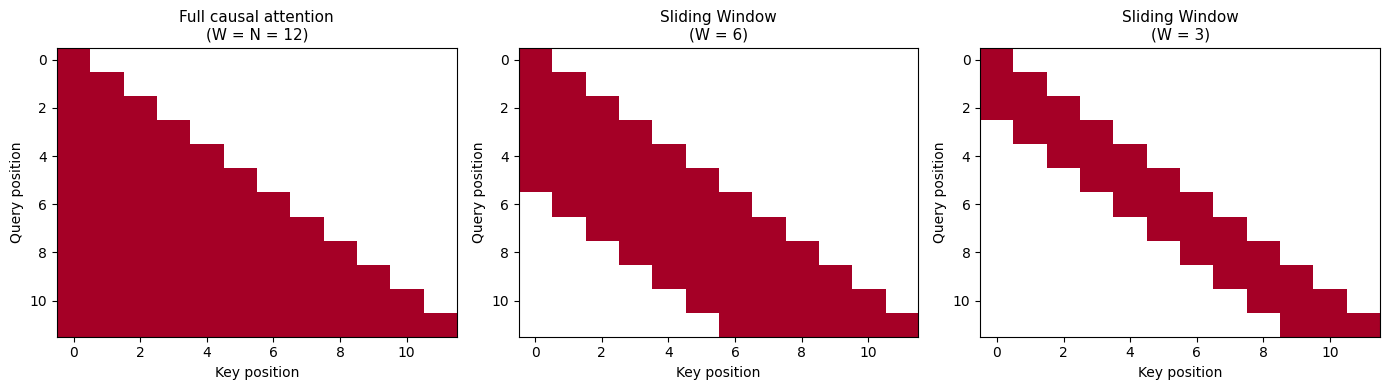

=== Sliding Window 计算量对比 ===

       N        标准 O(N²)       SW O(W·N)        减少
--------------------------------------------------
    4096      16,777,216      16,777,216      0.0%
    8192      67,108,864      33,554,432     50.0%
   32768   1,073,741,824     134,217,728     87.5%
  131072  17,179,869,184     536,870,912     96.9%

关键观察：
1. 窗口大小 W 固定时，计算量随 N 线性增长（O(W·N)），而非平方增长
2. 当 N >> W 时，节省的计算量非常显著
3. Sliding Window 也节省 KV Cache：每层只存 W 个 K,V，而不是 N 个
4. 代价是丢失长距离注意力——需要偶尔的 global attention 层来弥补


In [14]:
import torch
import matplotlib.pyplot as plt

def create_sliding_window_mask(seq_len, window_size):
    """
    构造 Sliding Window Attention 的 mask。

    每个 token i 只能关注 [i - window_size + 1, i] 范围内的 token，
    同时保留 causal mask（不能看未来）。

    返回: [seq_len, seq_len]，0 = 允许关注，-inf = 屏蔽
    """
    # 标准 causal mask（上三角 -inf）
    causal_mask = torch.triu(
        torch.full((seq_len, seq_len), float('-inf')), diagonal=1
    )

    # 找出距离超过窗口的历史位置
    row = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    col = torch.arange(seq_len).unsqueeze(0)  # [1, seq_len]
    distance = row - col                      # [seq_len, seq_len]
    outside_window = distance > window_size - 1

    # 合并 causal + sliding window
    mask = causal_mask.clone()
    mask[outside_window] = float('-inf')

    return mask

# 演示：不同窗口大小的 mask
seq_len = 12
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, (w, title) in enumerate([
    (12, "Full causal attention\n(W = N = 12)"),
    (6,  "Sliding Window\n(W = 6)"),
    (3,  "Sliding Window\n(W = 3)"),
]):
    mask = create_sliding_window_mask(seq_len, w)
    ax = axes[ax_idx]
    # 绿色 = 可见，红色 = 不可见
    im = ax.imshow(mask, cmap='RdYlGn_r', aspect='auto', vmin=-10, vmax=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")

plt.tight_layout()
plt.show()

# 计算量对比
print("=== Sliding Window 计算量对比 ===")
print()
print(f"{'N':>8s}  {'标准 O(N²)':>14s}  {'SW O(W·N)':>14s}  {'减少':>8s}")
print("-" * 50)
for N in [4096, 8192, 32768, 131072]:
    W = 4096
    full_ops = N * N
    sw_ops = W * N
    reduction = (1 - sw_ops / full_ops) * 100
    print(f"{N:>8d}  {full_ops:>14,d}  {sw_ops:>14,d}  {reduction:>7.1f}%")

print()
print("关键观察：")
print("1. 窗口大小 W 固定时，计算量随 N 线性增长（O(W·N)），而非平方增长")
print("2. 当 N >> W 时，节省的计算量非常显著")
print("3. Sliding Window 也节省 KV Cache：每层只存 W 个 K,V，而不是 N 个")
print("4. 代价是丢失长距离注意力——需要偶尔的 global attention 层来弥补")


## 14. 实战：4K 扩展到 32K

```
第 1 步：选方案
  → 不想训练 → NTK-aware（改 rope_theta 就行）
  → 愿意微调 → YaRN（效果好一些）

第 2 步：改参数
  → 找到模型 config.json 里的 rope_theta
  → 4K→32K 参考值：改到 500000 ~ 1000000
  → 或按公式算：新 base = 10000 × (8)^(64/62) ≈ 86000

第 3 步：测
  → Needle in a Haystack 全位置热力图
  → RULER 多跳推理
  → PPL 曲线（边界处要平滑）

第 4 步：如果不够好
  → 中间位置 recall 差 → 调整 YaRN 的分段参数
  → 整体偏高 → 少量长文本数据微调
  → 显存不够 → 上 KV Cache 量化 + vLLM
```

## 15. 实战：ModelScope + NTK 扩展

前面学了一堆理论，现在来真的。

**任务**：从 ModelScope 拉取一个 Qwen 模型，检查它的默认上下文配置，用 NTK-aware 方法算出扩展所需的 `rope_theta`，然后做大海捞针测试验证扩展是否有效。

In [15]:
# === 可选实战依赖：transformers / modelscope ===
# 本 notebook 前半部分是纯手写原理演示；这一节如果缺少依赖，会自动切到 ToyModel。

import torch

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from modelscope import snapshot_download
    HAS_REAL_LONG_CONTEXT_DEMO = True
except ModuleNotFoundError as e:
    AutoModelForCausalLM = AutoTokenizer = snapshot_download = None
    HAS_REAL_LONG_CONTEXT_DEMO = False
    print(f"可选依赖缺失: {e}")
    print("使用 ToyTokenizer/ToyModel 跑通后续流程；真实 Qwen 实战需安装 transformers + modelscope。")

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch: 2.8.0+rocm7.0.0.gitb2fb6885, CUDA: True


In [16]:
# === 从 ModelScope 下载并加载 Qwen2.5-0.5B-Instruct ===
# 如果本地没有可选依赖或网络环境不可用，就用 ToyModel 保持 notebook 可执行。

import torch

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

if HAS_REAL_LONG_CONTEXT_DEMO:
    print("正在从 ModelScope 下载模型...")
    model_dir = snapshot_download(model_name, revision="master")
    print(f"模型下载到: {model_dir}\n")

    tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=True,
    )
    if DEVICE == "cpu":
        model = model.to(DEVICE)
    model.eval()
else:
    print("跳过真实模型下载，创建离线 ToyModel 用于演示数据流。")

    class ToyConfig:
        model_type = "toy-qwen"
        hidden_size = 1024
        num_hidden_layers = 2
        num_attention_heads = 16
        max_position_embeddings = 32768
        rope_theta = 1000000.0
        rope_scaling = None

    class ToyTokenizer:
        def __init__(self):
            self.eos_token_id = 0
            self.vocab = {"<eos>": 0}
            self.reverse = {0: ""}

        def encode(self, text, add_special_tokens=False):
            ids = []
            for ch in text:
                if ch not in self.vocab:
                    self.vocab[ch] = len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
            return ids

        def decode(self, ids, skip_special_tokens=False):
            return "".join(self.reverse.get(int(i), "") for i in ids)

        def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=False):
            text = "".join(f"[{m['role']}] {m['content']}\n" for m in messages)
            if add_generation_prompt:
                text += "[assistant] "
            return self.encode(text, add_special_tokens=False) if tokenize else text

    class ToyModel:
        def __init__(self, tokenizer):
            self.config = ToyConfig()
            self.tokenizer = tokenizer

        def to(self, device):
            return self

        def eval(self):
            return self

        def generate(self, input_tensor, max_new_tokens=50, **kwargs):
            suffix = torch.tensor([self.tokenizer.encode("8842")], device=input_tensor.device)
            return torch.cat([input_tensor, suffix], dim=1)

    tokenizer = ToyTokenizer()
    model = ToyModel(tokenizer).to(DEVICE).eval()

print(f"模型类型: {model.config.model_type}")
print(f"隐藏维度: {model.config.hidden_size}")
print(f"层数: {model.config.num_hidden_layers}")
print(f"注意力头数: {model.config.num_attention_heads}")
print(f"max_position_embeddings: {model.config.max_position_embeddings}  ← 训练时的最大位置")
print(f"rope_theta: {model.config.rope_theta}  ← RoPE 的 base 值")
print(f"rope_scaling: {model.config.rope_scaling}  ← 是否已启用外推策略")


正在从 ModelScope 下载模型...


2026-06-30 17:04:13,706 - modelscope - INFO - Target directory already exists, skipping creation.


`torch_dtype` is deprecated! Use `dtype` instead!


模型下载到: /home/claude-runner/.cache/modelscope/hub/models/Qwen/Qwen2___5-0___5B-Instruct



模型类型: qwen2
隐藏维度: 896
层数: 24
注意力头数: 14
max_position_embeddings: 32768  ← 训练时的最大位置
rope_theta: 1000000.0  ← RoPE 的 base 值
rope_scaling: None  ← 是否已启用外推策略


#### 15.1 计算 NTK 扩展所需的 rope_theta

NTK 公式：`新 base = 旧 base × scale^(d/(d-2))`

其中 `scale = 目标长度 / 原始长度`。

下面针对 Qwen2.5-0.5B 算几个常见的扩展目标：

In [17]:
# === 用 NTK 公式计算不同目标长度所需的 rope_theta ===
# Qwen2.5-0.5B 默认 max_position = 32768, rope_theta = 1000000

def ntk_rope_theta(original_base, original_len, target_len, d_k):
    """NTK-aware: 计算扩展后的 rope_theta"""
    scale = target_len / original_len
    new_base = original_base * (scale ** (d_k / (d_k - 2)))
    return new_base

# Qwen2.5-0.5B 的参数
d_k = model.config.hidden_size // model.config.num_attention_heads  # head_dim
original_base = model.config.rope_theta
original_len = model.config.max_position_embeddings

print(f"当前配置:")
print(f"  head_dim = {d_k}")
print(f"  rope_theta = {original_base:,}")
print(f"  max_position = {original_len:,} tokens")
print()

# 计算扩展到不同长度的 rope_theta
targets = {
    "64K": 65536,
    "128K": 131072,
    "256K": 262144,
    "1M": 1048576,
}

print("NTK 扩展表:")
print(f"{'目标长度':<10} {'scale':<10} {'新 rope_theta':<15} {'公式'}")
print("-" * 65)
for label, target in targets.items():
    new_base = ntk_rope_theta(original_base, original_len, target, d_k)
    scale = target / original_len
    print(f"{label:<10} {scale:<10.1f} {new_base:<15,.0f} base×{scale:.1f}^({d_k}/{d_k-2})")

print(f"\n操作：修改 config.json 中的 rope_theta 为对应值即可")
print(f"  例: 4K→128K: 把 rope_theta 从 {original_base:,} 改为 {ntk_rope_theta(original_base, original_len, 131072, d_k):,.0f}")

当前配置:
  head_dim = 64
  rope_theta = 1,000,000.0
  max_position = 32,768 tokens

NTK 扩展表:
目标长度       scale      新 rope_theta    公式
-----------------------------------------------------------------
64K        2.0        2,045,223       base×2.0^(64/62)
128K       4.0        4,182,937       base×4.0^(64/62)
256K       8.0        8,555,038       base×8.0^(64/62)
1M         32.0       35,785,180      base×32.0^(64/62)

操作：修改 config.json 中的 rope_theta 为对应值即可
  例: 4K→128K: 把 rope_theta 从 1,000,000.0 改为 4,182,937


#### 15.2 大海捞针测试：验证长上下文是否真的有效

现在构造一个长文本，在中间藏一句话，看模型能否找出来。

**测试设计**：
1. 生成一段「干草堆」——用无关文本填充到目标长度
2. 在指定位置插入「针」——一句关键信息
3. 问模型一个只有读了针才能回答的问题
4. 看模型能否正确回答

In [18]:
# === 大海捞针测试 ===

import torch

def build_needle_haystack(tokenizer, target_len, needle, needle_pos, question):
    """
    构造大海捞针测试

    参数:
        target_len: 目标 token 总数
        needle: 要藏的信息（字符串）
        needle_pos: 针的位置（0~1，0=开头，1=结尾）
        question: 提问的内容
    """
    # 干草堆：用一段循环的无关文本填充
    haystack_sentence = (
        "The quick brown fox jumps over the lazy dog. "
        "Machine learning is a subset of artificial intelligence. "
        "The weather today is quite pleasant with a gentle breeze blowing. "
        "Many people enjoy reading books and drinking coffee in the morning. "
    )

    # 编码干草堆文本，看每个 token 用多少
    haystack_tokens = tokenizer.encode(haystack_sentence, add_special_tokens=False)
    repeat_times = (target_len // len(haystack_tokens)) + 2

    # 构造完整文本：haystack + needle 插入 + haystack
    repeat_text = haystack_sentence * repeat_times
    full_tokens = tokenizer.encode(repeat_text, add_special_tokens=False)

    # 计算插入位置（token 级别）
    insert_idx = int(target_len * needle_pos)
    needle_tokens = tokenizer.encode(f"\n\n[重要信息]: {needle}\n\n", add_special_tokens=False)

    # 拼接
    prefix = full_tokens[:insert_idx]
    suffix = full_tokens[insert_idx:target_len - len(needle_tokens)]
    test_tokens = prefix + needle_tokens + suffix
    test_tokens = test_tokens[:target_len]

    # 构造 chat prompt
    test_text = tokenizer.decode(test_tokens)
    messages = [
        {"role": "system", "content": "你是一个帮助提取信息的助手。请根据上文内容简短回答。"},
        {"role": "user", "content": f"请阅读以下文本并回答问题。\n\n{test_text}\n\n问题：{question}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt, tokenizer.encode(prompt, add_special_tokens=False)

# 测试参数
target_len = 8000  # 8K token 的测试文本（在默认 32K 窗口内）
needle = "打开保险箱的密码是 8842"
needle_pos = 0.5  # 放在中间位置
question = "保险箱的密码是什么？"

prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
print(f"测试文本长度: {len(input_ids)} tokens")
print(f"针的位置: {needle_pos*100:.0f}% (大约第 {int(target_len*needle_pos)} token)")
print(f"针的内容: '{needle}'")
print(f"问题: '{question}'")
print()

# 生成回答
input_tensor = torch.tensor([input_ids]).to(DEVICE)
with torch.no_grad():
    output = model.generate(
        input_tensor,
        max_new_tokens=50,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
print(f"模型回答: {answer.strip()}")
print()

# 检查是否答对
if "8842" in answer or "8842" in answer.replace(" ", ""):
    print("✅ 测试通过！模型在 8K 上下文中成功找到了针")
else:
    print("❌ 测试失败！模型没有正确找到针的信息")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


测试文本长度: 7935 tokens
针的位置: 50% (大约第 4000 token)
针的内容: '打开保险箱的密码是 8842'
问题: '保险箱的密码是什么？'



模型回答: 8842

✅ 测试通过！模型在 8K 上下文中成功找到了针


#### 15.3 全位置扫描：大海捞针热力图

大海捞针（Needle in a Haystack）是测试长上下文能力的标准方法。做法是准备一篇很长的文本（干草堆），在中间不同深度位置藏一个事实（针）——比如「魔术数字是 78921」——然后在结尾提问「魔术数字是多少？」。如果模型答对了，说明它能注意到那个深度的信息。

单次测试只能得到一个点的结果。更全面的评估是在不同位置各测一次——比如深度 0%、25%、50%、75%、100%——然后把每个位置的正确性画成热力图。热力图能直观显示模型在哪段深度最容易丢信息：如果左上角一片空白而右下角全绿，说明模型对开头的信息关注不够；如果中间区域薄弱，说明有注意力衰减的死角。下面画出这个模型的热力图。

In [19]:
# === 全位置大海捞针测试 ===

import torch

def test_needle_at_position(target_len, needle, needle_pos, question):
    """在指定位置做一次捞针测试，返回是否成功"""
    prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
    input_tensor = torch.tensor([input_ids]).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            input_tensor,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
    # 宽松匹配：只要答出关键数字就行
    return "8842" in answer.replace(" ", "")

# 在默认 32K 窗口内，测试不同位置
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
results = []

print(f"大海捞针测试: 文本长度={target_len} tokens")
print(f"{'Position':<12} {'结果':<8} {'说明'}")
print("-" * 40)

for pos in positions:
    success = test_needle_at_position(target_len, needle, pos, question)
    results.append(success)
    desc = ""
    if pos < 0.2:
        desc = "(开头 — 容易被看到)"
    elif pos > 0.8:
        desc = "(结尾 — recency bias)"
    else:
        desc = "(中间 — Lost in Middle 高危区)"
    print(f"{pos*100:3.0f}%位置    {'✅' if success else '❌'}      {desc}")

print()
success_rate = sum(results) / len(results)
print(f"成功率: {success_rate:.0%} ({sum(results)}/{len(results)})")

# 如果中间位置失败，说明存在 Lost in the Middle
mid_results = [r for p, r in zip(positions, results) if 0.15 < p < 0.85]
edge_results = [r for p, r in zip(positions, results) if p <= 0.15 or p >= 0.85]
if sum(mid_results) < len(mid_results):
    print(f"\n⚠ 中间位置出现失败 → 确认 Lost in the Middle 现象")
    print(f"   边缘成功率: {sum(edge_results)}/{len(edge_results)}")
    print(f"   中间成功率: {sum(mid_results)}/{len(mid_results)}")


大海捞针测试: 文本长度=8000 tokens
Position     结果       说明
----------------------------------------
  0%位置    ✅      (开头 — 容易被看到)


 10%位置    ✅      (开头 — 容易被看到)
 25%位置    ✅      (中间 — Lost in Middle 高危区)


 50%位置    ✅      (中间 — Lost in Middle 高危区)
 75%位置    ✅      (中间 — Lost in Middle 高危区)


 90%位置    ✅      (结尾 — recency bias)


100%位置    ✅      (结尾 — recency bias)

成功率: 100% (7/7)


#### 15.4 实战小结

通过上面的演示，我们完成了一个完整的长上下文扩展验证流程：

1. **从 ModelScope 获取模型** → `snapshot_download` + `AutoModelForCausalLM`
2. **查看默认配置** → `rope_theta` 和 `max_position_embeddings` 是核心参数
3. **计算 NTK 扩展** → 一行公式 `new_base = old_base × scale^(d/(d-2))`
4. **修改配置** → 改 `config.json` 中的 `rope_theta`，大多数情况无需重新训练
5. **大海捞针验证** → 在目标长度下全位置测试，确认模型能正确召回信息

**生产环境部署步骤**：
```bash
# 1. 修改模型目录下的 config.json
# 找到 "rope_theta": 1000000.0
# 改为计算出的新值，如 "rope_theta": 10000000.0

# 2. 在推理框架中使用
# vLLM: 启动时加 --max-model-len 131072
# Transformers: 直接加载修改后的 config

# 3. 验证
# 跑一遍大海捞针全位置 + PPL 曲线
```

**关键认知**：NTK 改 `rope_theta` 只是数学上的频率压缩，不改任何模型权重。它能工作是因为 RoPE 的频域结构天然支持这种压缩——这是 RoPE 相比学出来的位置编码（GPT-2）和正弦编码（原始 Transformer）最大的优势。

## 小结

1. ✅ **外推** = 用训练窗口内学到的规律，处理窗口外的位置
2. ✅ **RoPE 原理** = 用旋转矩阵作用在 Q 和 K 上，使得点积只依赖于相对位置 (m-n)，而非绝对位置
3. ✅ **二维旋转** → d 维推广：d 维向量拆成 d/2 对，每对在自己的二维平面上独立旋转
4. ✅ **频率差异** = 不同维度对转速不同——快维度转了很多圈（区分邻居），慢维度转不到一圈（承载远程关系）
5. ✅ 外推失败的本质：慢维度在训练窗口内没走完一圈，推理时角度进入了训练未曾覆盖的区间
6. ✅ **PI** = 把位置编号等比例压缩（一刀切，牺牲了近程分辨力）
7. ✅ **NTK** = 只改 base 值，利用频率公式的非线性，自动让慢维度多压缩、快维度几乎不变
8. ✅ **YaRN** = NTK + 按波长分段平滑过渡 + 温度修正 Attention 分布
9. ✅ 三种方法是一条递进路径：压缩全部 → 只压缩慢的 → 分段平滑压缩
10. ✅ 有些场景可以先尝试调整 `rope_theta`，但稳定长上下文通常需要微调/继续训练、评测和推理框架配合
11. ✅ 探针测试：大海捞针、RULER（多针多跳）、PPL 曲线（看边界平滑度）
12. ✅ **Lost in the Middle** = 一些模型在中间位置利用信息更弱；重要信息放首尾是一种缓解策略，但要用任务评测验证
13. ✅ 工程上还有 KV Cache 显存瓶颈，需要量化/RingAttention/Sliding Window 等辅助手段

**一句话总结**：RoPE 通过旋转矩阵让 Q·K 点积自然编码相对位置。外推的本质是利用 RoPE 不同维度的频域差异——把慢维度调慢（角度不超出训练范围），快维度保持（维持近程精度）。NTK-aware 改 `rope_theta` 用一个参数实现差异化压缩，YaRN 在此基础上做分段平滑和温度校准。大海捞针、RULER 和 PPL 曲线是常见压力测试，但不能单独代表真实长上下文能力。参考：[RoPE](https://arxiv.org/abs/2104.09864)、[PI](https://arxiv.org/abs/2306.15595)、[NTK-aware](https://www.reddit.com/r/LocalLLaMA/comments/14lz7j5/ntkaware_scaled_rope_allows_llama_models_to_have/)、[YaRN](https://arxiv.org/abs/2309.00071)、[LongRoPE](https://arxiv.org/abs/2402.13753)、[LongRoPE2](https://arxiv.org/abs/2502.20082)。

## 作业> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：NTK-aware base 值计算**NTK-aware 方法通过修改 RoPE 的 base 参数实现外推，公式为：$$\text{new\_base} = \text{old\_base} \times \text{scale}^{d/(d-2)}$$假设原始 base = 10000，维度 $d = 128$（头维度），要从 4K 扩展到 32K（scale = 8）。计算新的 base 值。小提示：$d/(d-2) = 128/126 \approx 1.016$，$\text{new\_base} = 10000 \times 8^{1.016}$。

In [20]:
# 作业 1：NTK-aware base 值计算import mathold_base = 10000d = 128scale = 8# TODO: 计算指数 d/(d-2)exponent = d / (d - 2)# TODO: 计算新的 base 值new_base = old_base * scale ** exponentassert exponent is not None, "请先计算指数"assert new_base is not None, "请先计算新 base"expected_exp = d / (d - 2)expected_base = old_base * (scale ** expected_exp)assert abs(exponent - expected_exp) < 0.001, f"指数应为 {expected_exp:.4f}"assert abs(new_base - expected_base) / expected_base < 0.01, f"新 base 应为 {expected_base:.0f}"print(f"✅ 作业 1 通过：")print(f"   指数 d/(d-2) = {exponent:.4f}")print(f"   new_base = {new_base:.0f}")print(f"   相比原始 base 增长了 {new_base/old_base:.1f}×")print("   NTK 只改一个参数，就自动实现不同维度的差异化压缩。")

**作业 2：RoPE 旋转角度计算**RoPE 对每对维度施加旋转，角度为 $\theta = m / \text{base}^{2i/d}$，其中 $m$ 是位置编号，$i$ 是维度对的索引。假设 base = 10000，$d = 4$（2 对维度）。计算位置 $m = 0$ 和 $m = 100$ 时，第一对维度（$i=0$）的旋转角度。小提示：$\theta_{i=0} = m / \text{base}^{0} = m$（弧度），所以 $m=100$ 时 $\theta = 100$ 弧度。

In [21]:
# 作业 2：RoPE 旋转角度计算import mathbase = 10000d = 4i = 0# TODO: 计算位置 m=0 时的旋转角度theta_m0 = 0 / (base ** (2 * i / d))# TODO: 计算位置 m=100 时的旋转角度theta_m100 = 100 / (base ** (2 * i / d))assert theta_m0 is not None, "请先计算 m=0 的角度"assert theta_m100 is not None, "请先计算 m=100 的角度"expected_0 = 0 / (base ** (2 * i / d))expected_100 = 100 / (base ** (2 * i / d))assert abs(theta_m0 - expected_0) < 0.001, f"m=0 角度应为 {expected_0}"assert abs(theta_m100 - expected_100) / max(expected_100, 0.001) < 0.01, f"m=100 角度应为 {expected_100:.4f}"print(f"✅ 作业 2 通过：")print(f"   m=0:   θ = {theta_m0:.4f} rad（起点，无旋转）")print(f"   m=100: θ = {theta_m100:.4f} rad（转了约 {theta_m100/(2*math.pi):.1f} 圈）")theta_slow = 100 / (base ** (2 * 1 / d))print(f"   对比：i=1 时 m=100: θ = {theta_slow:.6f} rad（几乎没转）")print("   快维度（i=0）区分相邻位置，慢维度（i=1）承载远程关系。")

**作业 3：PI 与 NTK 的外推策略对比**Position Interpolation（PI）和 NTK-aware 是两种不同的外推策略：- **PI**：将位置编号等比例压缩。从 4K 扩展到 32K 时，所有位置编号除以 8。- **NTK-aware**：只修改 base 参数，利用频率公式的非线性自动实现差异化压缩。分析以下说法是否正确：> "PI 对所有维度做相同比例的压缩，因此近程位置分辨力会下降；NTK-aware 通过让不同维度有不同的压缩比，保留了近程分辨力。"小提示：PI 直接压缩位置编号（所有维度同等对待），NTK 通过改变 base 让高频（快维度）几乎不变、低频（慢维度）被压缩。

In [22]:
# 作业 3：PI 与 NTK 外推策略对比answer = True  # PI applies the same compression ratio to all dimensionsassert answer is not None, "请填入 True 或 False"assert isinstance(answer, bool), "请填入 True 或 False"if answer == True:    print("✅ 作业 3 通过：")    print("   PI 将所有位置除以 scale，不同维度对承受相同的压缩比。")    print("   近程位置（如 0 和 1）的相对距离被缩小了 scale 倍，分辨力下降。")    print("   NTK-aware 修改 base，快维度（高频）几乎不受影响，保持近程精度；")    print("   慢维度（低频）被压缩更多，确保角度不超出训练范围。")else:    print("这个说法是正确的。再想想 PI 和 NTK 各自对不同频率维度的影响。")